In [1]:
from contextlib import contextmanager
import time

@contextmanager
def timer(label="block"):
    start = time.perf_counter()
    yield
    print(f"{label}: {time.perf_counter() - start:.4f}s")

In [6]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from glob import glob
import tqdm

import numpy as np
from collections import defaultdict

data_dir = "/scratch/shared/beegfs/piyush/datasets/text_data"

def read_txt_partial(path, nlines=128):
    data = []
    with open(path, "r") as f:
        for _ in range(nlines):
            line = f.readline()
            if not line:  # EOF reached
                break
            data.append(line)
    return ''.join(data)

In [44]:
def merge_pair(indices, pair):
    new_indices = []
    j = 0
    while j < len(indices):
        if j < len(indices) - 1 and indices[j] == pair[0] and indices[j+1] == pair[1]:
            new_indices.append(n)
            j += 2
        else:
            new_indices.append(indices[j])
            j += 1
    return new_indices

In [46]:
path = f"{data_dir}/TinyStoriesV2-GPT4-train.txt"
data = read_txt_partial(path, 150000)
print(data[:400])

# Get initial indices
# indices = np.array(list(data.encode("utf-8")))
indices = list(data.encode("utf-8"))
num_bytes = len(indices)
len(indices)

# Intialise the vocab: 256 bytes
vocab = {i: bytes([i]) for i in range(256)}
len(vocab)

# Intialise the merged: (i, j) -> k, where i, j should be be indices in vocab and k is a new index
merges = {}
compr_ratios = []

num_merges = 1000
for m in tqdm.tqdm(range(num_merges), desc="Adding merges"):

    # Count byte pairs
    counts = defaultdict(int)
    for j in range(len(indices) - 1):
        k = tuple((indices[j], indices[j+1]))
        counts[k] += 1
    max_pair = max(counts, key=counts.get)

    # Update the vocab
    n = len(vocab)
    vocab[n] = vocab[max_pair[0]] + vocab[max_pair[1]]
    merges[max_pair] = n
    
    # Replace wherever max_pair occurs with the new index n
    indices = merge_pair(indices, max_pair)

    compr_ratio = num_bytes / len(indices)
    compr_ratios.append(compr_ratio)


Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course y


Adding merges:   0%|▊                                                                                                                                                                                                                                                          | 3/1000 [00:33<3:08:10, 11.32s/it]


KeyboardInterrupt: 

In [49]:
path = f"{data_dir}/TinyStoriesV2-GPT4-train.txt"
data = read_txt_partial(path, 150000)
print(data[:400])

# Get initial indices
indices = np.array(list(data.encode("utf-8")))
# indices = list(data.encode("utf-8"))
num_bytes = len(indices)
len(indices)

# Intialise the vocab: 256 bytes
vocab = {i: bytes([i]) for i in range(256)}
len(vocab)

# Intialise the merged: (i, j) -> k, where i, j should be be indices in vocab and k is a new index
merges = {}
compr_ratios = []

num_merges = 1000
for m in tqdm.tqdm(range(num_merges), desc="Adding merges"):

    # Find count for each pair
    pairs = np.stack([indices[:-1], indices[1:]]).astype(int)
    unique_pairs, inverse_pairs, counts_pairs  = np.unique(pairs, axis=1, return_counts=True, return_inverse=True)
    max_pair = unique_pairs.T[counts_pairs.argmax()].astype(int)

    # Add to vocab
    # vocab[curr_index] = bytes(list(max_pair))
    n = len(vocab)
    vocab[n] = vocab[max_pair[0]] + vocab[max_pair[1]]

    # Add to merges
    merges[str(list(max_pair))] = n

    # Update the indices
    idx_replace = np.where(inverse_pairs == counts_pairs.argmax())[0]
    indices[idx_replace] = n
    indices = np.delete(indices, idx_replace + 1)

    compr_ratio = num_bytes / len(indices)
    compr_ratios.append(compr_ratio)


Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course y


Adding merges:   0%|▎                                                                                                                                                                                                                                                         | 1/1000 [01:13<20:16:29, 73.06s/it]


KeyboardInterrupt: 

### With pre-tokenisation

In [51]:
import regex as re

PAT = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""

# Example usage
re.findall(PAT, "some text that i'll pre-tokenize")

['some', ' text', ' that', ' i', "'ll", ' pre', '-', 'tokenize']

In [43]:
with timer("Counting with loop"):

    # Count byte pairs
    counts = defaultdict(int)
    # occurs = defaultdict(list)
    for j in range(len(indices) - 1):
        k = tuple((indices[j], indices[j+1]))
        counts[k] += 1
        # occurs[k].append(j)
    max_pair = max(counts, key=counts.get)
    # max_pair = max(occurs, key=lambda k: len(occurs[k]))

    # Update the vocab
    n = len(vocab)
    vocab[n] = vocab[max_pair[0]] + vocab[max_pair[1]]
    merges[max_pair] = n
    
    # Replace wherever max_pair occurs with the new index n
    indices = merge(indices, max_pair)
    
len(new_indices)

NameError: name 'merge' is not defined

In [42]:
max_pair

(101, 32)

In [39]:
len(new_indices), len(indices)

(433051, 448687)

In [29]:
len(new_indices), len(indices)

(448686, 448687)

In [26]:
with timer("Counting with loop"):
    
    
len(new_indices)

Counting with loop: 0.1120s


448686

In [23]:
len(max_pair_occurs)

15636

In [25]:
max_pair

(101, 32)

In [24]:
np.array(indices)[max_pair_occurs]

array([101, 101, 101, ..., 101, 101, 101], shape=(15636,))

In [ ]:
occurs

In [14]:
with timer("Get indices where max_pair appears"):
    max_pair_indices = [j for j in range(len(indices) - 1) if (indices[j], indices[j+1]) == max_pair]
len(max_pair_indices)

Get indices where max_pair appears: 0.0701s


15636

In [15]:
np.array(max_pair_indices)

array([     4,     16,     22, ..., 448598, 448623, 448677],
      shape=(15636,))

In [5]:
max_pair

array([101,  32])

In [4]:
with timer("Counting with np.unique"):
    unique_pairs, inverse_pairs, counts_pairs  = np.unique(pairs, axis=1, return_counts=True, return_inverse=True)
    max_pair = unique_pairs.T[counts_pairs.argmax()].astype(int)

Counting with np.unique: 0.4366s


In [163]:
pairs[0, j]

np.int64(10)

In [162]:
counts

defaultdict(int, {})

In [160]:
indices, len(indices)

(array([ 10,  79, 110, ...,  97,  46,  10], shape=(448687,)), 448687)

In [159]:
pairs

array([[ 10,  79, 110, ..., 110,  97,  46],
       [ 79, 110,  99, ...,  97,  46,  10]], shape=(2, 448686))

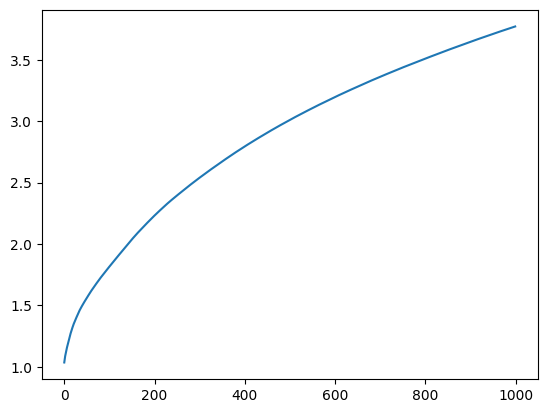

In [150]:
import matplotlib.pyplot as plt
plt.plot(compr_ratios)

In [143]:
"<|endoftext|>" in data

True